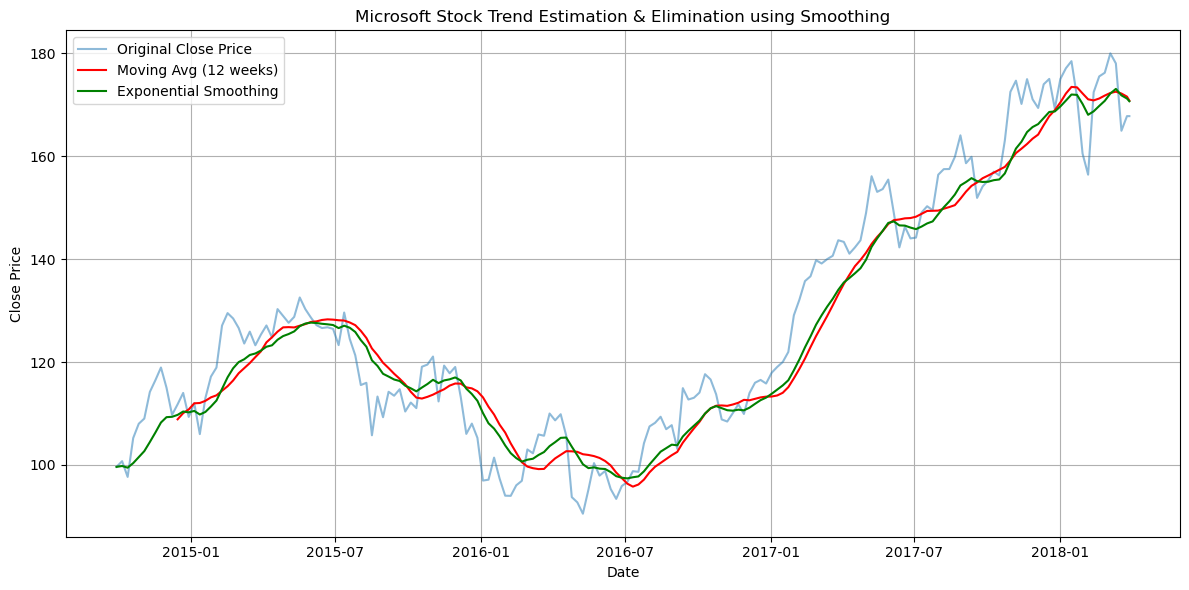

In [1]:
# Experiment 4: Trend Estimation & Elimination using Smoothing (Microsoft Stock Data)

# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load the dataset
df = pd.read_csv("microsoft.csv")  # Use correct path if needed

# Step 3: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 4: Set 'Date' as index
df.set_index('Date', inplace=True)

# Step 5: Aggregation - Monthly & Yearly Average of Close Price
df_monthly = df['Close'].resample('M').mean()
df_yearly = df['Close'].resample('Y').mean()

# Step 6: Moving Average Smoothing (Rolling Mean)
df['Moving_Avg'] = df['Close'].rolling(window=12).mean()

# Step 7: Exponential Smoothing
df['Exp_Smooth'] = df['Close'].ewm(span=12, adjust=False).mean()

# Step 8: Plot Original vs Smoothed Data
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label="Original Close Price", alpha=0.5)
plt.plot(df['Moving_Avg'], label="Moving Avg (12 weeks)", color='red')
plt.plot(df['Exp_Smooth'], label="Exponential Smoothing", color='green')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Microsoft Stock Trend Estimation & Elimination using Smoothing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()